# Prototype clean copernicus 

In [32]:
import pandas as pd
import os

# Set

In [33]:
year = 2024

    # cmems_mod_med_phy-tem_anfc_4.2km_P1D-m
    # cmems_mod_med_bgc-pft_anfc_4.2km_P1D-m
product_name = 'cmems_mod_med_phy-tem_anfc_4.2km_P1D-m'
input_path = "../data/raw"
df_name = f"{product_name}_{year}.parquet"

export_path = '../data/interim'
export_name = f"cleaned_{df_name}"
out = os.path.join(export_path, export_name)


# Import 

In [34]:
input = os.path.join(input_path, df_name)
df = pd.read_parquet(input)

# Check unique depth

In [35]:
df.head()

,depth,latitude,longitude,time,bottomT,thetao
0,1.018237,45.479168,13.166667,2024-01-01,13.325116,13.304394
1,1.018237,45.479168,13.166667,2024-01-02,13.248754,13.248711
2,1.018237,45.479168,13.166667,2024-01-03,13.210032,13.063446
3,1.018237,45.479168,13.166667,2024-01-04,13.120708,12.772483
4,1.018237,45.479168,13.166667,2024-01-05,13.103276,13.004619


In [36]:
if len(df['depth'].unique()) != 1:
    raise ValueError("DataFrame contains multiple depth levels.")

# Drop useless columns

In [37]:
df = df.drop(columns=['depth'])

# Rename columns 

In [38]:
rename_dict = {'time':'date'}
df = df.rename(columns=rename_dict)

In [39]:
df.head()

,latitude,longitude,date,bottomT,thetao
0,45.479168,13.166667,2024-01-01,13.325116,13.304394
1,45.479168,13.166667,2024-01-02,13.248754,13.248711
2,45.479168,13.166667,2024-01-03,13.210032,13.063446
3,45.479168,13.166667,2024-01-04,13.120708,12.772483
4,45.479168,13.166667,2024-01-05,13.103276,13.004619


# Export 

In [40]:
df.to_parquet(out, index=False)

# Exploration

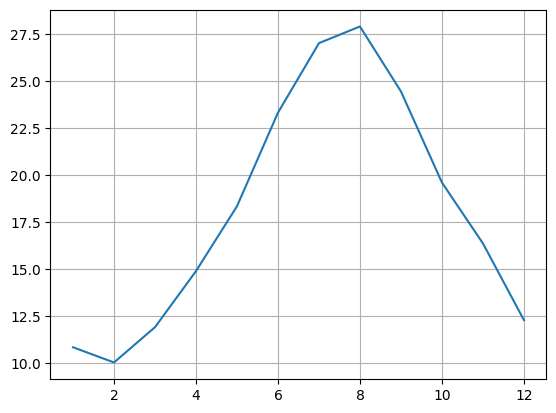

In [46]:
#df['month'] = df['date'].dt.month
#monthly_df = df.groupby('month').mean()

# Print thetao evolution through months 
import matplotlib.pyplot as plt 
plt.plot(monthly_df['thetao'])
plt.grid()
plt.show()


In [ ]:
spatial_keys = ['latitude','longitude']
spatial_df = df.groupby(spatial_keys).mean()



